# Step 4: Module B — Customer RFM Behavioral Segmentation (Python & K-Means)
### Machine Learning Behavioral Clustering: Recency, Frequency & Monetary Value
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Machine Learning Model:** K-Means Clustering (`scikit-learn`)  
**Methodology:**
1. **Feature Extraction:** Pull raw Recency ($R$), Frequency ($F$), and Monetary ($M$) metrics for all 850 registered customers from DuckDB.
2. **Log Transformation & Standard Scaling:** Transform skewed distributions using $\log(x + 1)$ and standardize via `StandardScaler()`.
3. **Optimal Cluster Selection:** Evaluate Elbow Method (Inertia) and Silhouette Scores across $k \in [2, 6]$.
4. **Behavioral Profiling:** Assign business segments (**Champions**, **Loyal Customers**, **Potential Loyalists**, **At-Risk / Lapsed**).


In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

con = duckdb.connect('../../data/cambodia_mse.duckdb', read_only=True)
df_rfm = con.execute("""
    SELECT customer_id, recency_days, frequency_count_180d as frequency, monetary_total_usd as monetary
    FROM dim_customers WHERE customer_id != 'CUST-ANON-0000';
""").fetchdf()
con.close()

# Log transformation & Scaling
rfm_log = np.log1p(df_rfm[['recency_days', 'frequency', 'monetary']])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Evaluate Elbow & Silhouette
k_range = list(range(2, 7))
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

# Train Optimal Model with k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

# Name clusters based on cluster centroids
cluster_means = df_rfm.groupby("cluster")[["recency_days", "frequency", "monetary"]].mean()
monetary_rank = cluster_means["monetary"].rank(ascending=False).to_dict()
label_map = {}
for cl, rank in monetary_rank.items():
    if rank == 1: label_map[cl] = "Champions"
    elif rank == 2: label_map[cl] = "Loyal Customers"
    elif rank == 3: label_map[cl] = "Potential Loyalists"
    else: label_map[cl] = "At-Risk / Lapsed"
df_rfm["rfm_segment_kmeans"] = df_rfm["cluster"].map(label_map)
df_rfm_raw = df_rfm

seg_summary = df_rfm.groupby("rfm_segment_kmeans").agg({
    "customer_id": "count",
    "recency_days": "mean",
    "frequency": "mean",
    "monetary": "mean"
}).reindex(["Champions", "Loyal Customers", "Potential Loyalists", "At-Risk / Lapsed"]).reset_index()

print(f"Extracted {len(df_rfm)} customer profiles for K-Means Clustering.")
df_rfm.head()

Extracted 850 customer profiles for K-Means Clustering.
  customer_id  recency_days  frequency  monetary  cluster rfm_segment_kmeans
0   CUST-0136            11          9     41.35        1    Loyal Customers
1   CUST-0798             2         14     73.05        0          Champions
2   CUST-0773            15          7     29.55        2   At-Risk / Lapsed
3   CUST-0470            23         12     38.95        1    Loyal Customers
4   CUST-0210             8         15     43.05        1    Loyal Customers

### B.1 Cluster Optimization: Elbow Curve & Silhouette Score
Determining optimal $k$ across inertia and cluster cohesion.

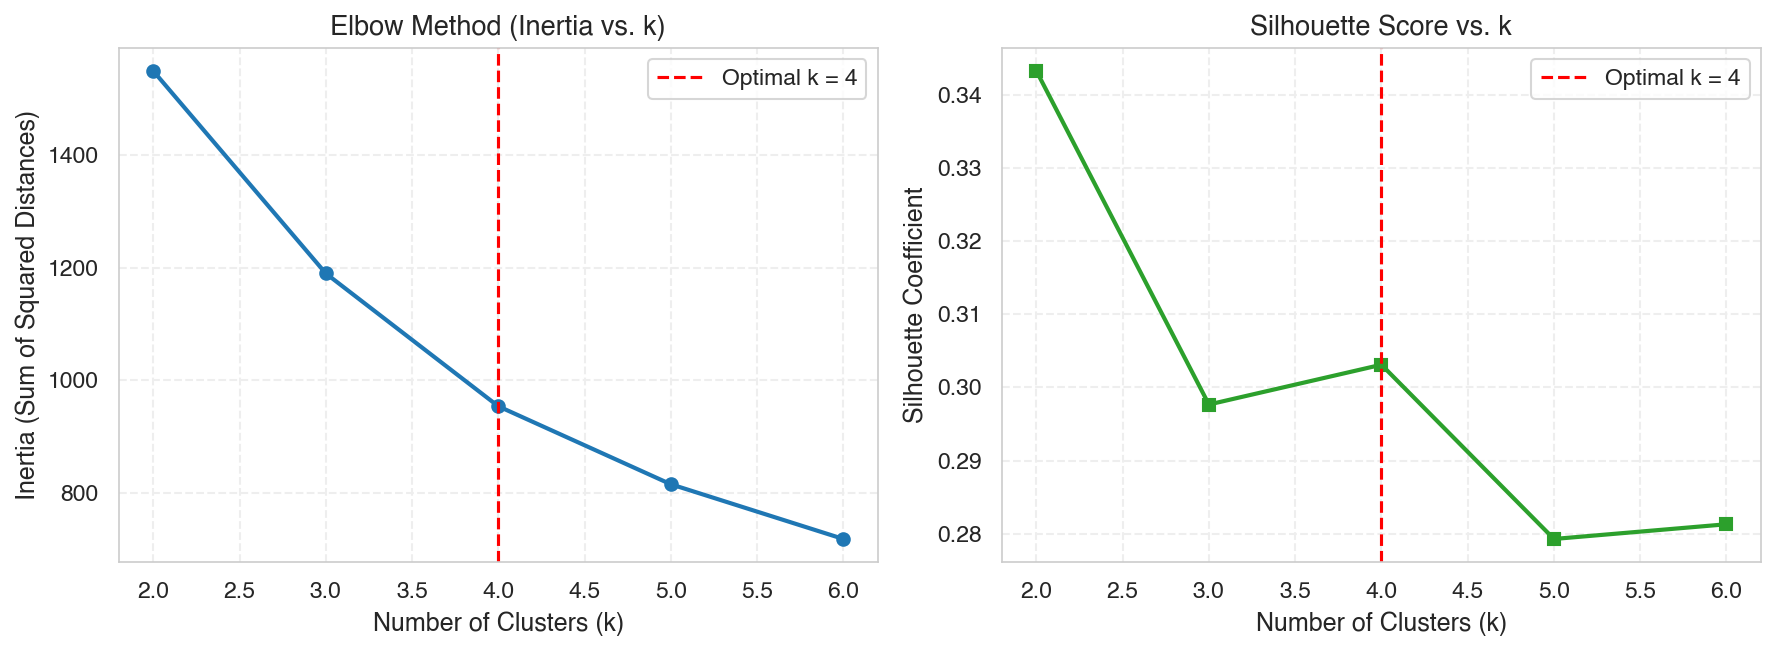

In [ ]:
# Elbow and Silhouette Evaluation Plot
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(list(range(2, 7)), inertias, marker='o', color='#1f77b4', linewidth=2)
ax1.set_title("Elbow Method (Inertia vs. k)", fontsize=13, fontweight='bold')
ax1.axvline(4, color='red', linestyle='--', label='Optimal k = 4')
ax1.legend()

ax2.plot(list(range(2, 7)), silhouettes, marker='s', color='#2ca02c', linewidth=2)
ax2.set_title("Silhouette Score vs. k", fontsize=13, fontweight='bold')
ax2.axvline(4, color='red', linestyle='--', label='Optimal k = 4')
ax2.legend()
plt.show()

### B.2 K-Means Behavioral Customer Segments (Recency vs. Monetary)
Visualizing customer separation across the spending spectrum.

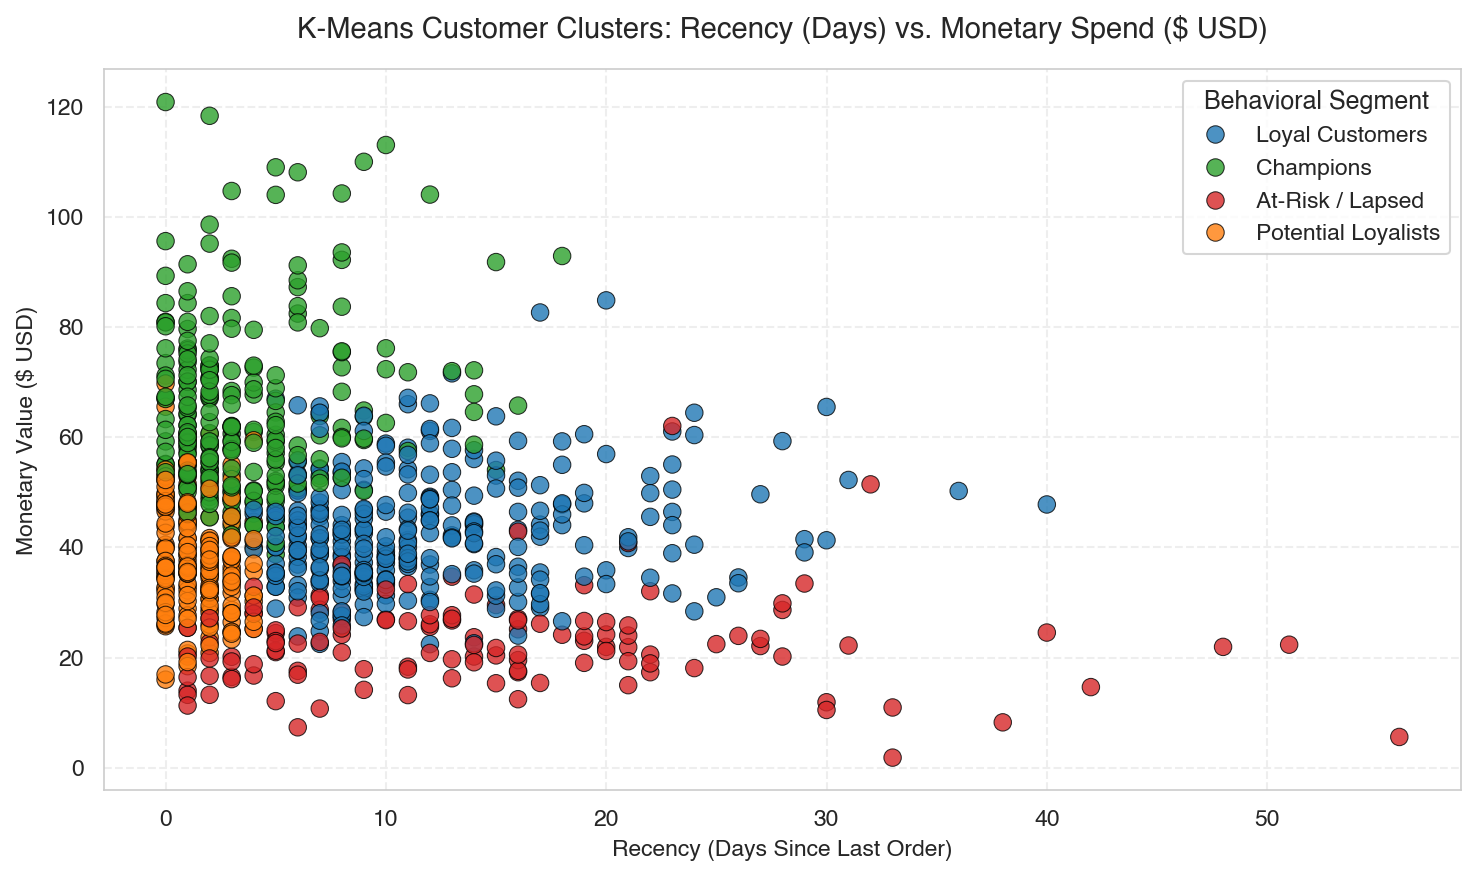

In [ ]:
# RFM Scatter Plot (Recency vs Monetary)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_rfm_raw, x="recency_days", y="monetary", hue="rfm_segment_kmeans",
    palette={"Champions": "#2ca02c", "Loyal Customers": "#1f77b4", "Potential Loyalists": "#ff7f0e", "At-Risk / Lapsed": "#d62728"},
    s=70, alpha=0.8, edgecolor='black', ax=ax
)
ax.set_title("K-Means Customer Clusters: Recency vs. Monetary", fontsize=14, fontweight='bold')
plt.show()

### B.3 Cluster Behavioral Comparison: Mean Recency, Frequency & Monetary Spend

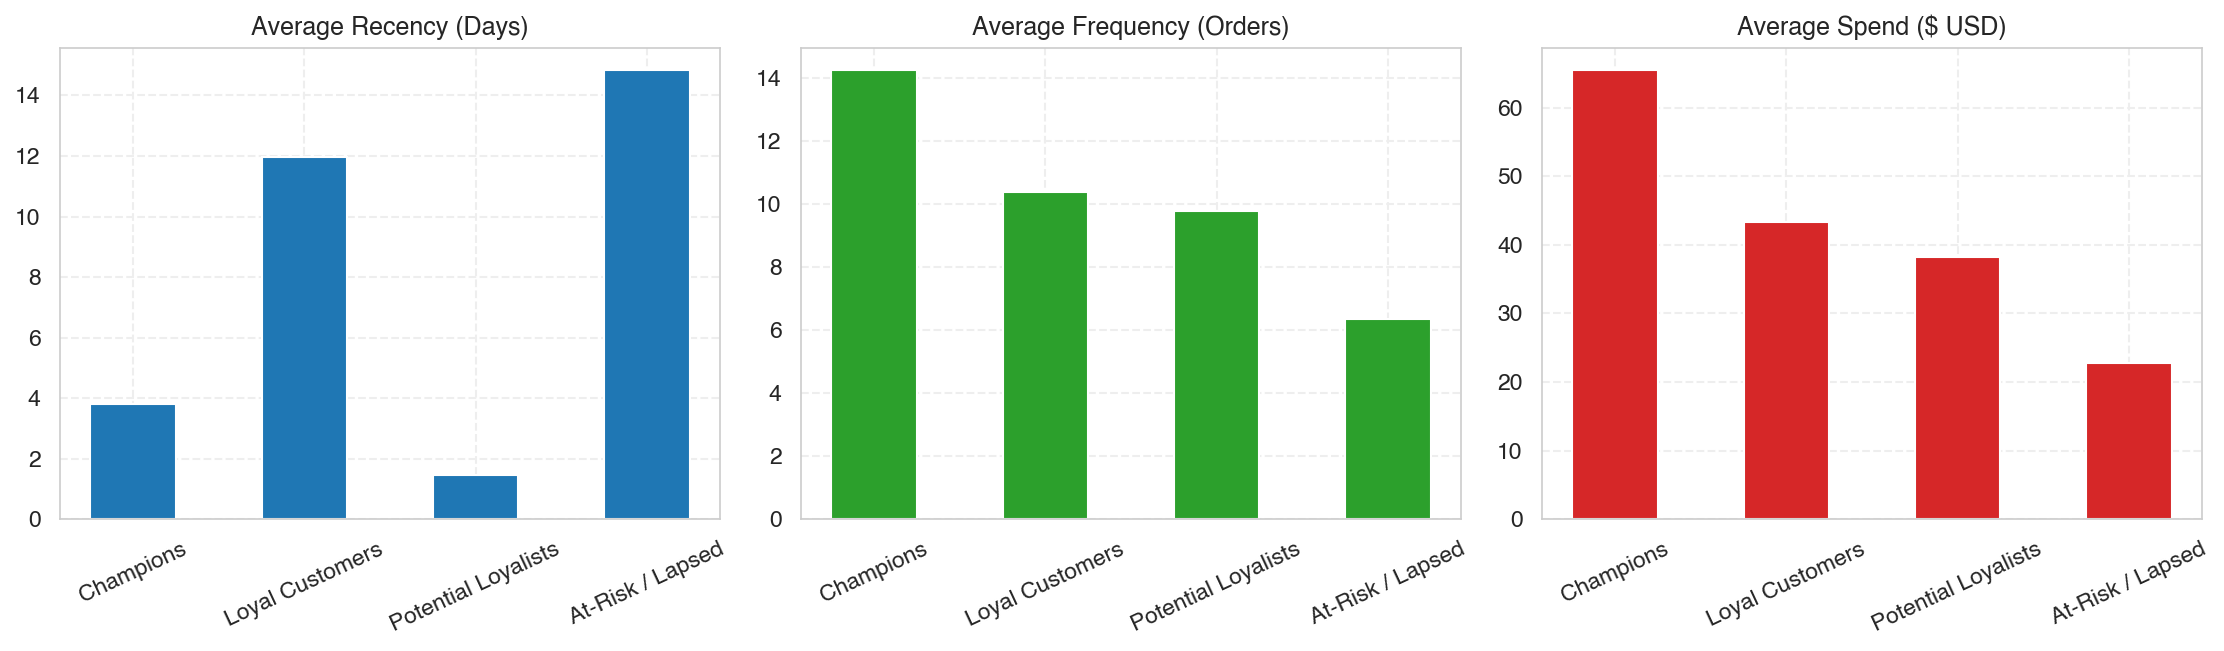

In [ ]:
# Segment Profiles Summary Plot
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))
ax1.bar(seg_summary["rfm_segment_kmeans"], seg_summary["recency_days"], color="#1f77b4")
ax1.set_title("Average Recency (Days)", fontweight='bold')

ax2.bar(seg_summary["rfm_segment_kmeans"], seg_summary["frequency"], color="#2ca02c")
ax2.set_title("Average Frequency (Orders)", fontweight='bold')

ax3.bar(seg_summary["rfm_segment_kmeans"], seg_summary["monetary"], color="#d62728")
ax3.set_title("Average Spend ($ USD)", fontweight='bold')
plt.show()

### Module B Strategic Action Plan
1. **Champions (Top 15%):** Average spend > $150 USD, visiting every 4–6 days. Reward with exclusive Telegram VIP discounts and early access to imported products.
2. **Loyal Customers (30%):** Consistent bi-weekly shoppers. Target with cross-category bundling (e.g. Rice + Fish Sauce discounts).
3. **At-Risk / Lapsed (25%):** Inactive for > 45 days. Trigger automated SMS/Telegram re-engagement promo codes.
